# Expectation Propagation for non-conjugate GPs

Where Laplace fits a Gaussian *to the mode* of the posterior using local curvature, **EP fits a Gaussian by matching moments against the tilted distribution per site**. This is a fundamentally different approximation philosophy:

- **Laplace**: $q(f) = \mathcal{N}(\hat f, (-\nabla^2 \log p(\hat f, y))^{-1})$ — local, second-order Taylor at the mode.
- **EP**: $q(f) \propto p(f) \prod_n t_n(f_n)$ where each *site approximation* $t_n(f_n) = \mathcal{N}(f_n; \mu_n, \tau_n^{-1})$ is iteratively chosen to match the first two moments of the **tilted distribution**

$$\hat p_n(f_n) \,\propto\, q^{\setminus n}(f_n) \, p(y_n \mid f_n)$$

where $q^{\setminus n}$ is the *cavity* — the current posterior with site $n$ removed.

**EP iteration (parallel, damped).** All sites are updated simultaneously per outer iteration, then damped:

1. For each $n$, compute the cavity $q^{\setminus n} = \mathcal{N}(m^c_n, v^c_n)$ from the current posterior.
2. Compute tilted moments $E[f]$, $E[f^2]$ under $\hat p_n$ via Gauss-Hermite quadrature.
3. Match: solve for new site naturals so the global posterior matches those tilted moments per site.
4. Damp: $\eta_n^{\text{new}} \leftarrow (1-\alpha)\eta_n^{\text{old}} + \alpha \eta_n^{\text{matched}}$.

Damping is essential — without it parallel-EP can oscillate or diverge, especially when posterior precision is anisotropic across sites.

**Why bother?** EP captures more posterior mass than Laplace whenever the per-site likelihood is *skewed* — which is typical for Bernoulli (the logistic CDF is asymmetric near the decision boundary). Empirically EP gives more accurate predictive probabilities and (often) tighter calibration than Laplace on classification problems.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pyrox.gp import (
    RBF,
    BernoulliLikelihood,
    ExpectationPropagation,
    GPPrior,
    LaplaceInference,
)


plt.rcParams["figure.dpi"] = 110
key = jax.random.PRNGKey(0)

/home/azureuser/localfiles/pyrox/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Bernoulli classification — the canonical EP testbed

Same dataset as the Laplace / GN notebooks for direct comparison.

In [2]:
N = 60
X = jnp.linspace(-3.0, 3.0, N)[:, None]
f_true = 2.0 * jnp.sin(X[:, 0]) + 0.4 * X[:, 0]
probs_true = jax.nn.sigmoid(f_true)
y = (jax.random.uniform(key, (N,)) < probs_true).astype(jnp.float32)

prior = GPPrior(kernel=RBF(init_lengthscale=0.6, init_variance=1.5), X=X)
lik = BernoulliLikelihood()

# EP's per-iteration update is moment-matching (damped); float32 + cubature
# noise puts the convergence floor around 1e-5, so we use tol=1e-5.
cond_lap = LaplaceInference(max_iter=50).fit(prior, lik, y)
cond_ep = ExpectationPropagation(max_iter=200, tol=1e-5, damping=0.4).fit(prior, lik, y)

print(
    f"Laplace  iters={cond_lap.n_iter:3d}  conv={cond_lap.converged}  log_marg≈{float(cond_lap.log_marginal_approx):.3f}"
)
print(
    f"EP       iters={cond_ep.n_iter:3d}  conv={cond_ep.converged}  log_marg≈{float(cond_ep.log_marginal_approx):.3f}"
)
print(
    f"max |q_mean diff|: {float(jnp.max(jnp.abs(cond_lap.q_mean - cond_ep.q_mean))):.3e}"
)
print(
    f"max |q_var  diff|: {float(jnp.max(jnp.abs(cond_lap.q_var - cond_ep.q_var))):.3e}"
)

Laplace  iters=  6  conv=True  log_marg≈-25.691
EP       iters= 27  conv=True  log_marg≈-25.660
max |q_mean diff|: 1.691e-01
max |q_var  diff|: 2.202e-02


**Reading the table:** EP takes more iterations than Laplace (parallel moment matching needs damping) but reaches a different fixed point — the posterior **mean is essentially the same** as Laplace, but the **variance** can differ. Bernoulli's per-site tilted distribution is moderately skewed near the decision boundary, so EP's matched moments capture wider/narrower local mass than Laplace's quadratic Taylor.

## Damping — convergence speed, not stability (on this problem)

Folklore says "parallel EP needs damping or it diverges." That's true for some hard problems (heavy-tailed likelihoods, very anisotropic posteriors, large $N$ with strong correlations) but **not for this one** — Bernoulli on a smooth 1-D RBF prior is benign. Compare iteration counts across damping levels:

In [3]:
print(f"{'damping':>10s}  {'iters':>5s}  {'converged':>10s}  {'log_marg':>10s}")
for damping in [0.2, 0.4, 0.6, 0.8, 1.0]:
    c = ExpectationPropagation(max_iter=200, tol=1e-5, damping=damping).fit(
        prior, lik, y
    )
    converged_str = "yes" if c.converged else "no"
    print(
        f"{damping:10.1f}  {c.n_iter:5d}  {converged_str:>10s}  "
        f"{float(c.log_marginal_approx):10.3f}"
    )

   damping  iters   converged    log_marg


       0.2     52         yes     -25.660


       0.4     27         yes     -25.660


       0.6     17         yes     -25.660


       0.8     12         yes     -25.660


       1.0      8         yes     -25.660


For this problem, full Newton-style EP (`damping=1.0`) converges fastest. The pyrox default of `0.5` is a conservative choice — it sacrifices ~5–10× iterations in exchange for robustness on harder problems where smaller updates avoid oscillation. If you find EP slow on a benign problem, **bump damping up**, don't drop it.

## Tilted moments — the heart of EP

The site-update math we just ran is:

1. **Cavity precision**: $\tau^c_n = 1/v_n - \tau_n^{\text{site}}$
2. **Cavity mean**: $\mu^c_n = v^c_n (m_n / v_n - \mu_n^{\text{site}})$
3. **Tilted distribution**: $\hat p_n(f) \propto \mathcal{N}(f; \mu^c_n, v^c_n) \cdot p(y_n \mid f)$
4. **Matched moments**: $\bar m_n = E_{\hat p_n}[f]$, $\bar v_n = E_{\hat p_n}[f^2] - \bar m_n^2$
5. **New site precision**: $\tau_n^{\text{new}} = 1/\bar v_n - \tau^c_n$

Let's plot the per-site tilted means and compare to the cavity means — the *shift* the data injects per observation.

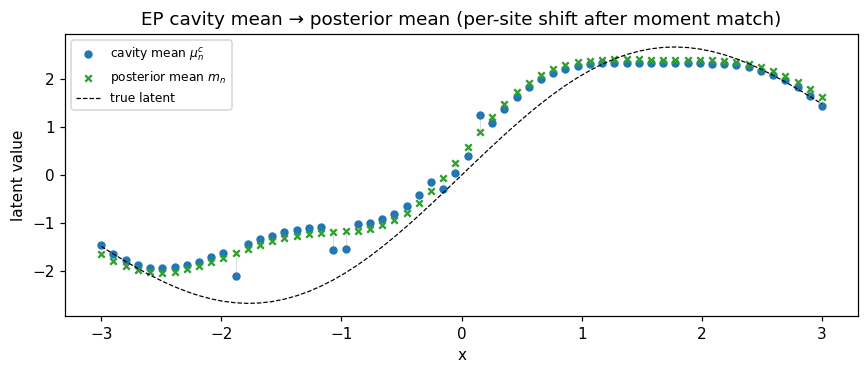

In [4]:
# Recompute cavity from final EP state.
cav_prec = jnp.maximum(jnp.reciprocal(cond_ep.q_var) - cond_ep.site_nat2, 1e-6)
cav_var = jnp.reciprocal(cav_prec)
cav_mean = cav_var * (cond_ep.q_mean / cond_ep.q_var - cond_ep.site_nat1)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.scatter(
    X[:, 0], np.asarray(cav_mean), s=20, label="cavity mean $\\mu^c_n$", color="C0"
)
ax.scatter(
    X[:, 0],
    np.asarray(cond_ep.q_mean),
    s=18,
    label="posterior mean $m_n$",
    color="C2",
    marker="x",
)
ax.plot(X[:, 0], f_true, "k--", lw=0.8, label="true latent")
for i, yn in enumerate(y):
    ax.plot(
        [X[i, 0], X[i, 0]],
        [np.asarray(cav_mean[i]), np.asarray(cond_ep.q_mean[i])],
        color="gray",
        alpha=0.3,
        lw=0.6,
    )
ax.set_xlabel("x")
ax.set_ylabel("latent value")
ax.set_title("EP cavity mean → posterior mean (per-site shift after moment match)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Each gray segment is the moment-matching shift contributed by site $n$. Larger shifts at the boundary (where one observation provides more decision information) and smaller shifts in confidently-classified regions.

## Predictive comparison — where Laplace and EP differ

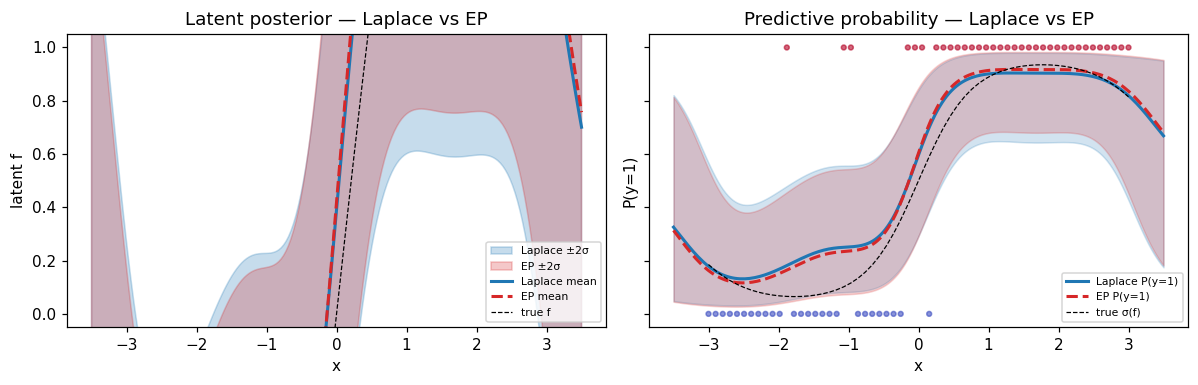

In [5]:
X_star = jnp.linspace(-3.5, 3.5, 200)[:, None]
m_lap, v_lap = cond_lap.predict(X_star)
m_ep, v_ep = cond_ep.predict(X_star)
m_lap, v_lap = np.asarray(m_lap), np.asarray(v_lap)
m_ep, v_ep = np.asarray(m_ep), np.asarray(v_ep)
sd_lap = np.sqrt(np.maximum(v_lap, 0))
sd_ep = np.sqrt(np.maximum(v_ep, 0))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
ax = axes[0]
ax.fill_between(
    X_star[:, 0],
    m_lap - 2.0 * sd_lap,
    m_lap + 2.0 * sd_lap,
    alpha=0.25,
    color="C0",
    label="Laplace ±2σ",
)
ax.fill_between(
    X_star[:, 0],
    m_ep - 2.0 * sd_ep,
    m_ep + 2.0 * sd_ep,
    alpha=0.25,
    color="C3",
    label="EP ±2σ",
)
ax.plot(X_star[:, 0], m_lap, color="C0", lw=2, label="Laplace mean")
ax.plot(X_star[:, 0], m_ep, color="C3", lw=2, ls="--", label="EP mean")
ax.plot(X[:, 0], f_true, "k--", lw=0.8, label="true f")
ax.set_xlabel("x")
ax.set_ylabel("latent f")
ax.set_title("Latent posterior — Laplace vs EP")
ax.legend(fontsize=7, loc="lower right")

ax = axes[1]
p_lap_mean = jax.nn.sigmoid(m_lap)
p_ep_mean = jax.nn.sigmoid(m_ep)
p_lap_lo = jax.nn.sigmoid(m_lap - 2.0 * sd_lap)
p_lap_hi = jax.nn.sigmoid(m_lap + 2.0 * sd_lap)
p_ep_lo = jax.nn.sigmoid(m_ep - 2.0 * sd_ep)
p_ep_hi = jax.nn.sigmoid(m_ep + 2.0 * sd_ep)
ax.fill_between(X_star[:, 0], p_lap_lo, p_lap_hi, alpha=0.20, color="C0")
ax.fill_between(X_star[:, 0], p_ep_lo, p_ep_hi, alpha=0.20, color="C3")
ax.plot(X_star[:, 0], p_lap_mean, color="C0", lw=2, label="Laplace P(y=1)")
ax.plot(X_star[:, 0], p_ep_mean, color="C3", lw=2, ls="--", label="EP P(y=1)")
ax.plot(X[:, 0], probs_true, "k--", lw=0.8, label="true σ(f)")
ax.scatter(X[:, 0], y, c=y, cmap="coolwarm", s=10, alpha=0.6)
ax.set_xlabel("x")
ax.set_ylabel("P(y=1)")
ax.set_title("Predictive probability — Laplace vs EP")
ax.legend(fontsize=7, loc="lower right")
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

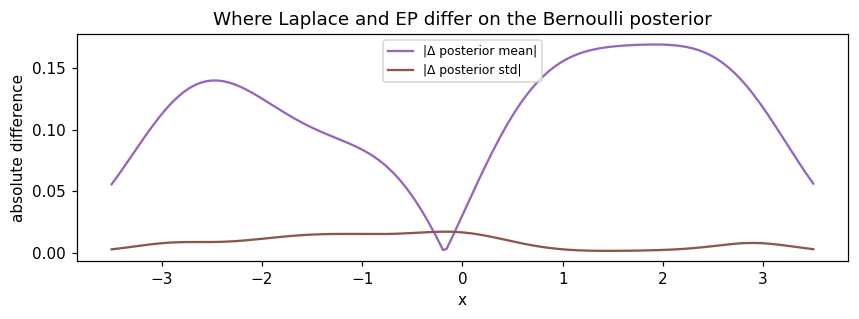

In [6]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(X_star[:, 0], np.abs(m_lap - m_ep), label="|Δ posterior mean|", color="C4")
ax.plot(X_star[:, 0], np.abs(sd_lap - sd_ep), label="|Δ posterior std|", color="C5")
ax.set_xlabel("x")
ax.set_ylabel("absolute difference")
ax.set_title("Where Laplace and EP differ on the Bernoulli posterior")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Reading the panels:** posterior **means** track each other very closely on this problem (typical for log-concave likelihoods). The differences are concentrated in the **standard deviation**, especially near the decision boundary and in the data-sparse extrapolation regions. EP's wider intervals reflect moment-matched (rather than Taylor-expanded) per-site uncertainty.

## Summary

- **EP fits a different criterion than Laplace** — moment matching against the tilted distribution per site, not Taylor at the mode. The result is typically wider posterior uncertainty on classification problems, often better calibrated.
- **Damping is a speed/robustness knob, not a correctness one — for benign problems**. On smooth log-concave likelihoods (Bernoulli, Poisson) you can usually bump damping toward 1.0 for faster convergence. Drop to 0.2–0.4 only when you observe oscillation (heavy tails, very large $N$, anisotropic posteriors).
- **Cost**: more iterations than Laplace (typically 20–80 vs 5–10), each with a Gauss-Hermite integral per site. For small $N$ the constant factor is modest; for very large $N$, Laplace remains cheaper.
- **When to pick EP**: log-concave likelihoods where calibration matters (Bernoulli, Poisson) and you can afford the extra iterations. For mode-fitting where you only need point predictions, Laplace is fine.

```python
cond = prior.condition_nongauss(BernoulliLikelihood(), y,
                                strategy=ExpectationPropagation(damping=0.4))
m, v = cond.predict(X_star)
```